# HippoRAG Pipeline Evaluation
This notebook executes the complete HippoRAG algorithm end-to-end using `ContrieverEmbedder` and `GeminiLLM`.
It loads the dataset, performs offline indexing, online retrieval, generates answers, and plots the evaluation metrics.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install -r "/content/drive/MyDrive/Data Mining Project/requirements.txt"

In [2]:
import sys
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add the src directory to the Python path
sys.path.append(os.path.abspath(os.path.join('..', '/content/drive/MyDrive/Data Mining Project/src')))

from hipporag import (
    DatasetLoader, GeminiLLM, HuggingFaceLLM, ContrieverEmbedder, OpenIEExtractor,
    QueryNERExtractor, KnowledgeGraph, PPRRunner, EntityLinker,
    RetrievalEngine, QAReader, Evaluator
)

## 1. Setup & Initialization
Initialize the LLM, Embedder, Extractors, Graph, and Reader.

In [ ]:
# Make sure to set your API key if running locally or in Colab secrets
os.environ['GEMINI_API_KEY'] = 'API_KEY_HERE'

# llm = GeminiLLM(model_name="gemini-flash-lite-latest", rate_limit_sleep=5)
llm = HuggingFaceLLM(model_name="Qwen/Qwen2.5-7B-Instruct")
embedder = ContrieverEmbedder() # Using facebook/contriever

openie = OpenIEExtractor(llm)
ner = QueryNERExtractor(llm)
kg = KnowledgeGraph()
ppr = PPRRunner(kg, damping=0.85)
reader = QAReader(llm)

Loading Qwen/Qwen2.5-7B-Instruct in 4-bit quantization...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: facebook/contriever
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 2. Load Dataset
Loading the small subset of HotpotQA for demonstration.

In [10]:
print("Loading data...")

queries, corpus = DatasetLoader.load_musique(
    '/content/drive/MyDrive/Data Mining Project/data/raw/musique.json',
    limit=5 # Running on 5 queries for the demo
)


print(f"Loaded {len(queries)} queries and {len(corpus)} passages.")

Loading data...
Loaded 5 queries and 78 passages.


## 3. Offline Indexing
Extract triples, embed passages and nodes, and build the Knowledge Graph.

In [11]:
print("Running Offline Indexing...")
passage_triples = {}
passage_embeddings = {}

# For the demo, we index a subset of passages to save time.
# In a real run, iterate over all passages in corpus.
sample_titles = list(corpus.keys())

for i, title in enumerate(sample_titles):
    p = corpus[title]
    print(f"Indexing [{i+1}/{len(sample_titles)}]: {title}")
    entities, triples = openie.extract(p.text)
    passage_triples[title] = triples
    passage_embeddings[title] = embedder.encode(p.text)[0]

print("Building Knowledge Graph...")
kg.build_from_triples([t for t_list in passage_triples.values() for t in t_list])

node_names = kg.get_nodes()
if node_names:
    node_embeddings = embedder.encode(node_names)
else:
    node_embeddings = []

print(f"KG built with {len(node_names)} nodes.")

Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running Offline Indexing...
Indexing [1/78]: Lionel Messi


Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Indexing [2/78]: FC Barcelona


Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Indexing [76/78]: 1923 World Figure Skating Championships


Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Indexing [77/78]: A Prisoner of Birth


Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Indexing [78/78]: Lordship of Frisia
Building Knowledge Graph...
KG built with 847 nodes.


## 4. Online Retrieval & Evaluation
Execute the retrieval engine and QA reader, then calculate metrics.

In [12]:
linker = EntityLinker(embedder, node_names, node_embeddings)
engine = RetrievalEngine(
    ner, linker, ppr, embedder,
    passage_embeddings, passage_triples, alpha=0.5
)

recall_at_5 = 0
exact_matches = 0
results_data = []

print("Running Online Retrieval and QA...")
for i, q in enumerate(queries):
    print(f"\n[{i+1}/{len(queries)}] Query: {q.question}")

    # Retrieve top 5 passages
    top_k = engine.retrieve(q.question, top_k=5)
    retrieved_titles = [t[0] for t in top_k]
    print(f"Retrieved: {retrieved_titles}")

    # Metric: Recall@5
    is_recalled = Evaluator.recall_at_k(set(retrieved_titles), q.gold_titles)
    if is_recalled:
        recall_at_5 += 1

    # Generate Answer
    retrieved_passages = [corpus[title] for title in retrieved_titles if title in corpus]
    answer = reader.generate_answer(q.question, retrieved_passages)
    print(f"Predicted Answer: {answer} | Gold: {q.answer}")

    # Metric: Exact Match
    em = Evaluator.exact_match(answer, q.answer)
    if em:
        exact_matches += 1

    results_data.append({
        'query_id': q.id,
        'recall': 1 if is_recalled else 0,
        'em': 1 if em else 0
    })

final_recall = recall_at_5 / len(queries)
final_em = exact_matches / len(queries)
print(f"\nFinal Recall@5: {final_recall*100:.2f}%")
print(f"Final Exact Match: {final_em*100:.2f}%")

Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running Online Retrieval and QA...

[1/5] Query: When was the person who Messi's goals in Copa del Rey compared to get signed by Barcelona?


Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Retrieved: ['FC Barcelona', 'El Clásico', 'List of Spanish football champions', 'Lionel Messi', 'List of La Liga top scorers']


Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Retrieved: ['Labyrinth (1984 video game)', "The Devil's Labyrinth", 'Minotaur: The Labyrinths of Crete', 'Acornsoft', 'Minos']


Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Predicted Answer: 1986 | Gold: 1986

[5/5] Query: When was Lady Godiva's birthplace abolished?


Both `max_new_tokens` (=2048) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Retrieved: ['Mercia', 'Spalding Priory', 'Lordship of Frisia', 'British nationality law', 'Dr. Seuss']
Predicted Answer: The passage does not mention Lady Godiva's birthplace or its abolition. Therefore, there is no information to answer this question based on the given passages. | Gold: 918

Final Recall@5: 80.00%
Final Exact Match: 60.00%


## 5. Plot Results
Visualizing the performance metrics of the pipeline.

/tmp/ipykernel_37628/528054913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Metric', y='Score (%)', data=df, palette='viridis')


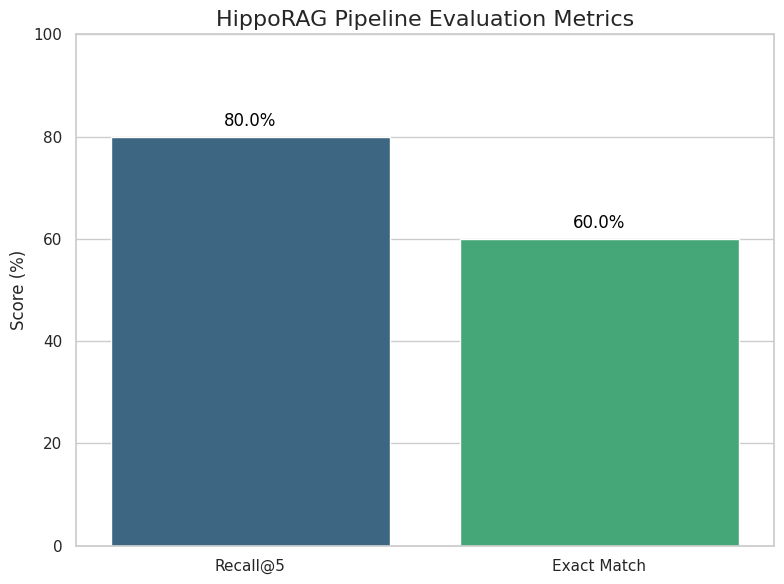

In [13]:
sns.set_theme(style="whitegrid")
metrics = ['Recall@5', 'Exact Match']
scores = [final_recall * 100, final_em * 100]

df = pd.DataFrame({'Metric': metrics, 'Score (%)': scores})

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Metric', y='Score (%)', data=df, palette='viridis')
plt.title('HippoRAG Pipeline Evaluation Metrics', fontsize=16)
plt.ylim(0, 100)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('', fontsize=12)

# Add value labels on top of bars
for i, p in enumerate(ax.patches):
    ax.annotate(f"{scores[i]:.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()